# ERA5 vs Observed Precipitation — Comparison & Analysis

This notebook addresses the following questions:
1. **Why are ERA5 and IGEBU precipitation values so different?**
2. **Visualising the difference** — time series overlays, scatter plots, bias plots
3. **Monthly correlation** between the two datasets
4. **How ERA5 data is collected** (model description)
5. **Distances between ERA5 grid points and actual station locations**

---
**Data sources used:**
- `data/outputs/master_dataset_monthly.csv` — merged dataset containing both `precip_observed` (IGEBU in-situ) and `era5_tp_sum` (ERA5 reanalysis)
- Station and ERA5 grid coordinates from `scripts/download/era5/README.md`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

ROOT = Path("../../")
df_all = pd.read_csv(ROOT / "data/outputs/master_dataset_monthly.csv", parse_dates=["date"])

# Keep only rows where both precipitation columns exist
df = df_all.dropna(subset=["precip_observed", "era5_tp_sum"]).copy()
df["month"] = df["date"].dt.month

print(f"Total rows with both precip columns: {len(df)}")
print(f"Rivers present: {sorted(df['river'].unique())}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print()
print(df[["precip_observed", "era5_tp_sum"]].describe().round(2))

Total rows with both precip columns: 3895
Rivers present: ['Buzimba', 'Jiji', 'Kaburantwa', 'Mpanda', 'Mulembwe', 'Mutimbuzi', 'Nyakagunda', 'Nyamagana', 'Nyengwe', 'Rusizi']
Date range: 1981-01-01 → 2024-12-01

       precip_observed  era5_tp_sum
count          3895.00      3895.00
mean             97.07       158.02
std              83.06       192.23
min               0.00         0.00
25%              23.70        15.17
50%              84.50        62.60
75%             148.40       261.63
max             556.60       945.92


---
## 1. Why are ERA5 and IGEBU precipitation values so different?

There are several fundamental reasons:

| Factor | IGEBU (observed) | ERA5 (reanalysis) |
|---|---|---|
| **Measurement type** | Physical rain gauge at a point location | Model output — combines satellite, radiosonde, and NWP model |
| **Spatial resolution** | Single point (~m²) | 0.25° grid cell (~28 × 28 km) |
| **What it represents** | Exact rainfall at that gauge | Spatial average over the ~780 km² grid cell |
| **Temporal resolution** | Monthly totals | Hourly, summed to monthly |
| **Topographic effect** | Captures orographic enhancement locally | Smoothed over a coarse grid — misses steep valley rainfall gradients |

In northern Burundi, orographic effects are strong: rivers drain steep catchments where rainfall varies dramatically over a few km. ERA5 at 0.25° resolution (~28 km) cannot resolve this local variability.

---
## 2. Distances between ERA5 grid points and actual station locations

ERA5 data was downloaded at the nearest 0.25° grid node to each station. The table below shows how far each station is from its ERA5 grid point — larger distances mean ERA5 is less representative of local conditions.

In [2]:
# Station coordinates (exact) and ERA5 grid points (from scripts/download/era5/README.md)
stations = [
    {"Station": "Nyanza Lac (IRAT)",         "Type": "temp/water level", "st_lat": -4.32, "st_lon": 29.62, "era5_lat": -4.25, "era5_lon": 29.50},
    {"Station": "Nyengwe (Rimbo)",            "Type": "water level",     "st_lat": -4.17, "st_lon": 29.54, "era5_lat": -4.25, "era5_lon": 29.50},
    {"Station": "Mulembwe (Mutambara)",       "Type": "water level",     "st_lat": -4.00, "st_lon": 29.44, "era5_lat": -4.00, "era5_lon": 29.50},
    {"Station": "Buzimba (Gatete)",           "Type": "water level",     "st_lat": -4.05, "st_lon": 29.48, "era5_lat": -4.00, "era5_lon": 29.50},
    {"Station": "Dama (Mbuga)",               "Type": "water level",     "st_lat": -3.95, "st_lon": 29.42, "era5_lat": -4.00, "era5_lon": 29.50},
    {"Station": "Jiji (Ndago)",               "Type": "water level",     "st_lat": -3.92, "st_lon": 29.64, "era5_lat": -4.00, "era5_lon": 29.75},
    {"Station": "Mpota (Tora)",               "Type": "temp/water level","st_lat": -3.73, "st_lon": 29.57, "era5_lat": -3.75, "era5_lon": 29.50},
    {"Station": "Rusizi (Gatumba)",           "Type": "water level",     "st_lat": -3.34, "st_lon": 29.27, "era5_lat": -3.25, "era5_lon": 29.25},
    {"Station": "Bujumbura (Aéroport)",       "Type": "temp/water level","st_lat": -3.32, "st_lon": 29.32, "era5_lat": -3.25, "era5_lon": 29.25},
    {"Station": "Mutimbuzi (Pont Aéroport)",  "Type": "water level",     "st_lat": -3.32, "st_lon": 29.33, "era5_lat": -3.25, "era5_lon": 29.25},
    {"Station": "Imbo (SEMS)",                "Type": "temperature",     "st_lat": -3.18, "st_lon": 29.35, "era5_lat": -3.25, "era5_lon": 29.25},
    {"Station": "Mpanda (Gatura)",            "Type": "water level",     "st_lat": -3.12, "st_lon": 29.40, "era5_lat": -3.00, "era5_lon": 29.50},
    {"Station": "Kaburantwa (Mission)",       "Type": "water level",     "st_lat": -2.99, "st_lon": 29.22, "era5_lat": -3.00, "era5_lon": 29.25},
    {"Station": "Rwegura",                    "Type": "temperature",     "st_lat": -2.92, "st_lon": 29.52, "era5_lat": -3.00, "era5_lon": 29.50},
    {"Station": "Nyamagana (Murambi)",        "Type": "water level",     "st_lat": -2.90, "st_lon": 29.13, "era5_lat": -3.00, "era5_lon": 29.25},
    {"Station": "Mparambo",                   "Type": "temperature",     "st_lat": -2.83, "st_lon": 29.08, "era5_lat": -2.75, "era5_lon": 29.00},
    {"Station": "Nyakagunda (Musenyi)",       "Type": "water level",     "st_lat": -2.76, "st_lon": 29.08, "era5_lat": -2.75, "era5_lon": 29.00},
]

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df_stations = pd.DataFrame(stations)
df_stations["distance_km"] = df_stations.apply(
    lambda r: haversine_km(r["st_lat"], r["st_lon"], r["era5_lat"], r["era5_lon"]), axis=1
).round(2)
df_stations["ERA5 grid"] = df_stations.apply(
    lambda r: f"{r['era5_lat']:.2f}, {r['era5_lon']:.2f}", axis=1
)
df_stations["Station coords"] = df_stations.apply(
    lambda r: f"{r['st_lat']:.2f}, {r['st_lon']:.2f}", axis=1
)

print(df_stations[["Station", "Station coords", "ERA5 grid", "distance_km"]]
      .sort_values("distance_km", ascending=False)
      .to_string(index=False))
print(f"\nMean distance: {df_stations['distance_km'].mean():.1f} km")
print(f"Max distance:  {df_stations['distance_km'].max():.1f} km  ({df_stations.loc[df_stations['distance_km'].idxmax(), 'Station']})")
print(f"Min distance:  {df_stations['distance_km'].min():.1f} km  ({df_stations.loc[df_stations['distance_km'].idxmin(), 'Station']})")

                  Station Station coords    ERA5 grid  distance_km
      Nyamagana (Murambi)   -2.90, 29.13 -3.00, 29.25        17.36
          Mpanda (Gatura)   -3.12, 29.40 -3.00, 29.50        17.36
        Nyanza Lac (IRAT)   -4.32, 29.62 -4.25, 29.50        15.42
             Jiji (Ndago)   -3.92, 29.64 -4.00, 29.75        15.10
              Imbo (SEMS)   -3.18, 29.35 -3.25, 29.25        13.56
                 Mparambo   -2.83, 29.08 -2.75, 29.00        12.57
Mutimbuzi (Pont Aéroport)   -3.32, 29.33 -3.25, 29.25        11.81
     Bujumbura (Aéroport)   -3.32, 29.32 -3.25, 29.25        11.00
             Dama (Mbuga)   -3.95, 29.42 -4.00, 29.50        10.47
         Rusizi (Gatumba)   -3.34, 29.27 -3.25, 29.25        10.25
          Nyengwe (Rimbo)   -4.17, 29.54 -4.25, 29.50         9.94
                  Rwegura   -2.92, 29.52 -3.00, 29.50         9.17
     Nyakagunda (Musenyi)   -2.76, 29.08 -2.75, 29.00         8.95
             Mpota (Tora)   -3.73, 29.57 -3.75, 29.50         

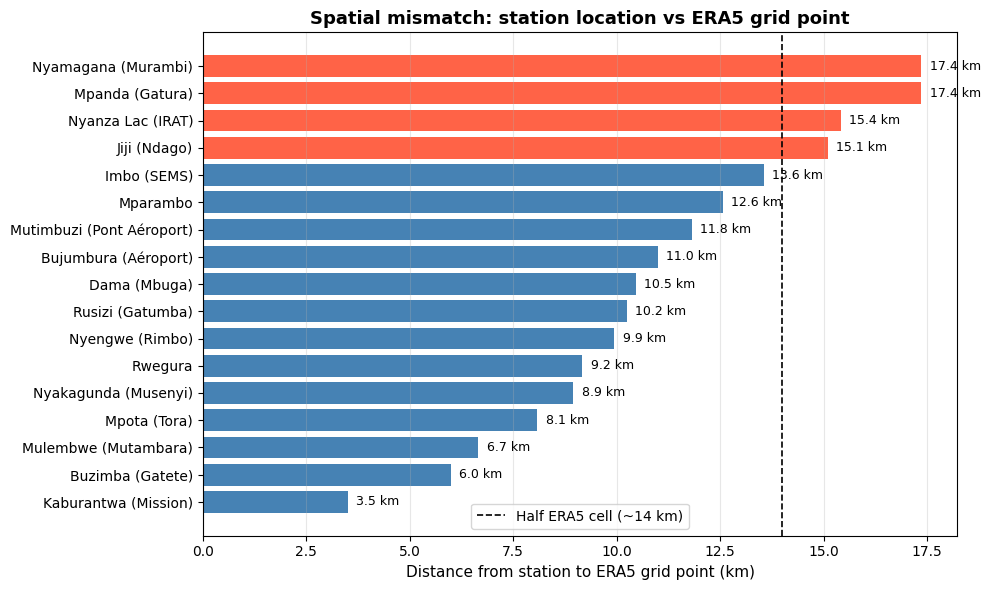

In [ ]:
# Bar chart of distances
df_plot = df_stations.sort_values("distance_km", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["tomato" if d > 15 else "steelblue" for d in df_plot["distance_km"]]
bars = ax.barh(df_plot["Station"], df_plot["distance_km"], color=colors)
ax.axvline(14.0, color="black", linestyle="--", linewidth=1.2, label="Half ERA5 cell (~14 km)")
ax.set_xlabel("Distance from station to ERA5 grid point (km)", fontsize=11)
ax.set_title("Spatial mismatch: station location vs ERA5 grid point", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, df_plot["distance_km"]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} km", va="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. How ERA5 data is collected

ERA5 is a reanalysis product produced by ECMWF (European Centre for Medium-Range Weather Forecasts). It is **not a direct measurement**, instead it combines:

- Numerical Weather Prediction (NWP) model — a physics-based atmospheric model run at ~31 km resolution (globally)
- Data assimilation (4D-Var) — assimilates billions of observations from:
  - Weather balloons (radiosondes)
  - Surface weather stations
  - Satellite brightness temperatures (AMSU, ATMS, etc.)
  - Aircraft measurements (AMDAR)
  - GPS radio occultation
  - Ocean buoys and ships


---
## 4. Visual comparison: time series overlay

One river at a time to make the difference easy to see.

C:\Users\luukj\AppData\Local\Temp\ipykernel_27332\4083753839.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rivers_with_obs = sorted(df.groupby("river").apply(lambda x: x["precip_observed"].notna().sum()).sort_values(ascending=False).index.tolist())


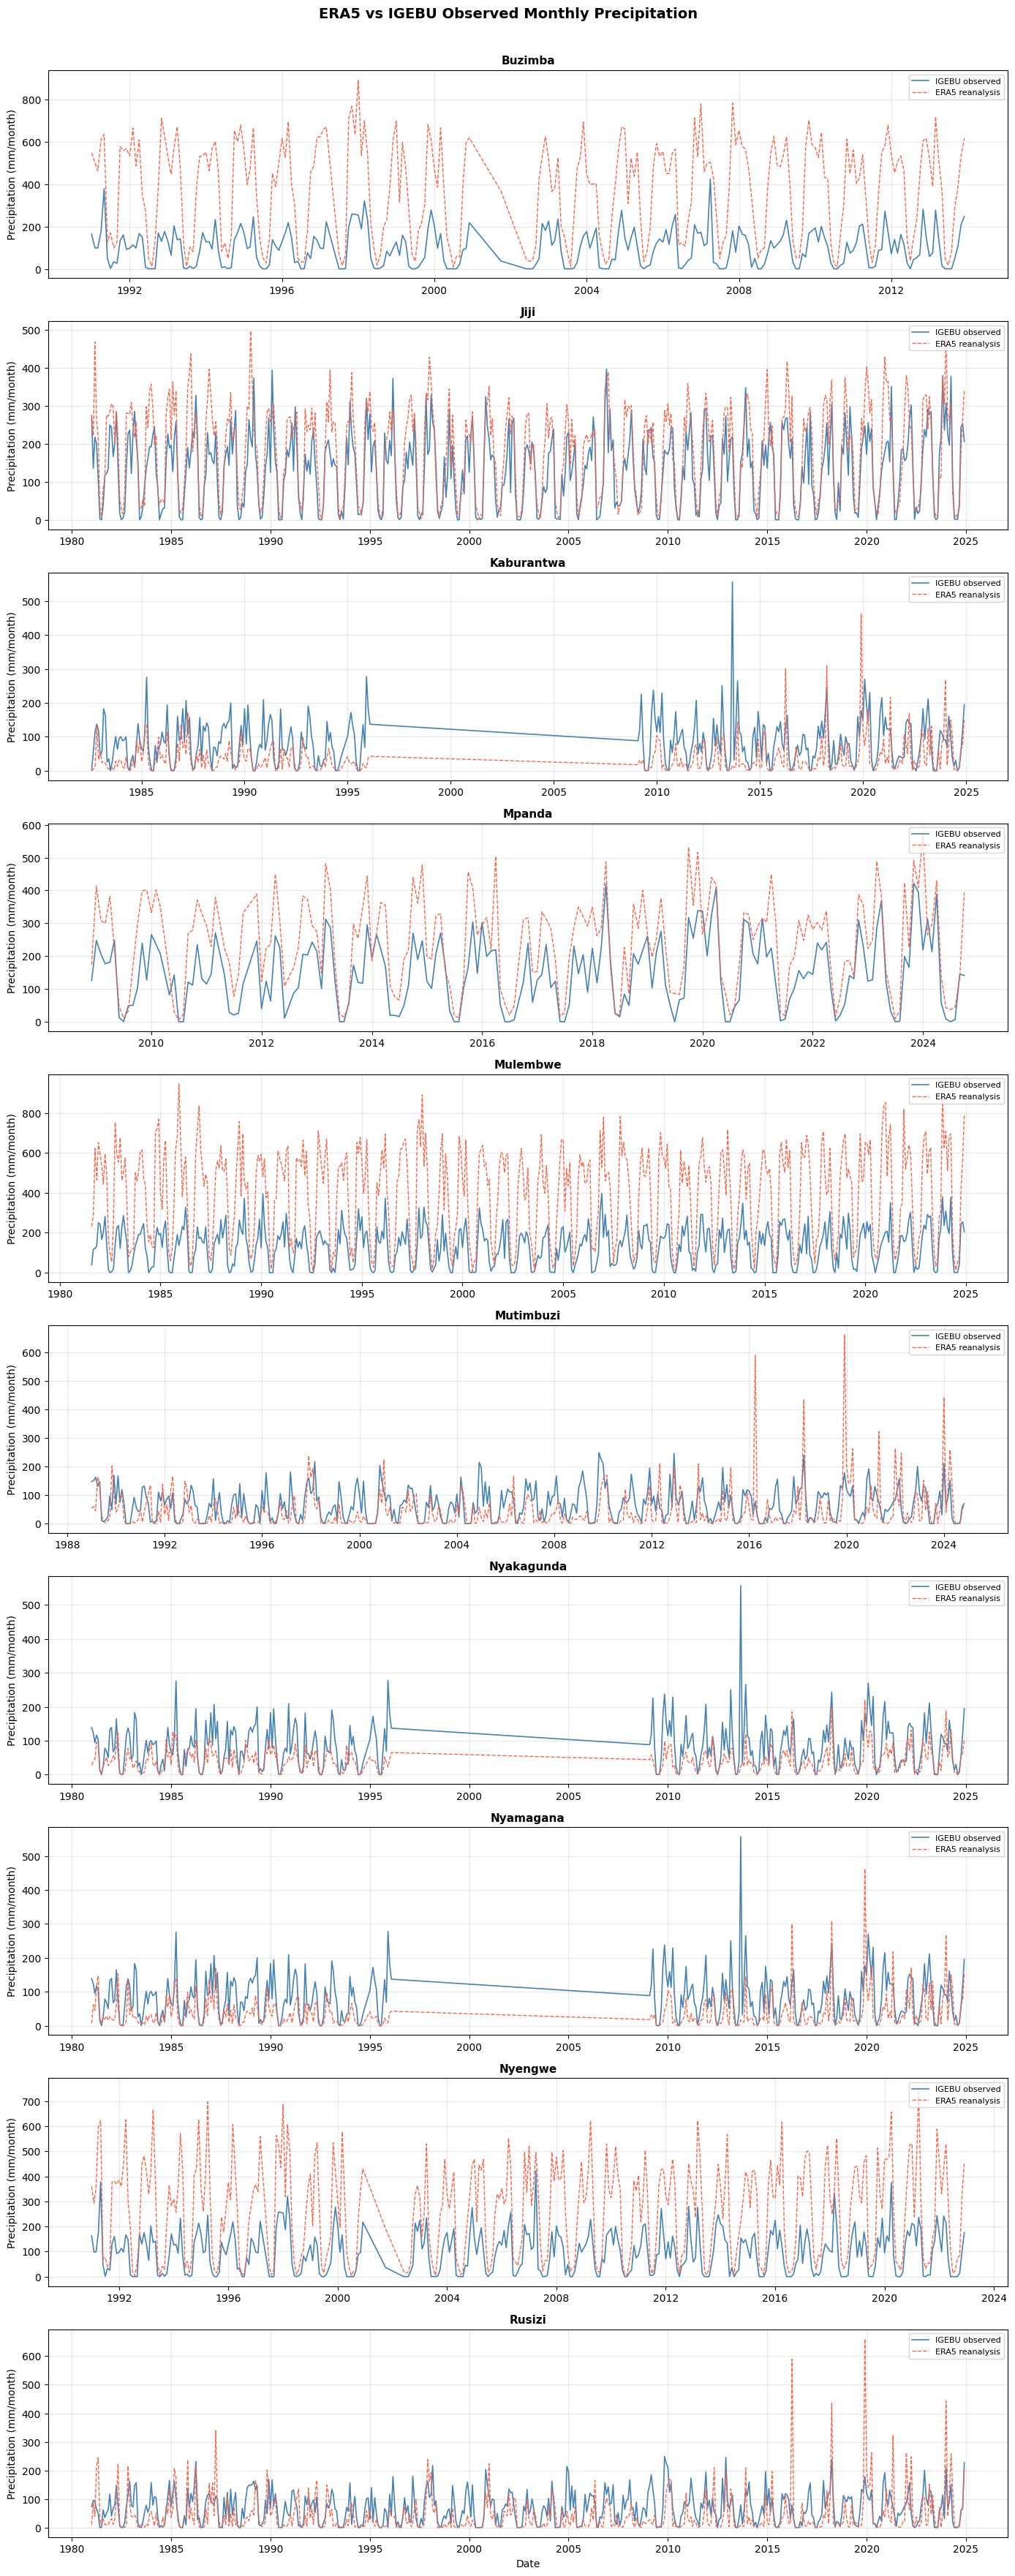

In [4]:
rivers_with_obs = sorted(df.groupby("river").apply(lambda x: x["precip_observed"].notna().sum()).sort_values(ascending=False).index.tolist())

n = len(rivers_with_obs)
fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, river in zip(axes, rivers_with_obs):
    sub = df[df["river"] == river].sort_values("date")
    ax.plot(sub["date"], sub["precip_observed"], color="steelblue", linewidth=1.2, label="IGEBU observed")
    ax.plot(sub["date"], sub["era5_tp_sum"], color="tomato", linewidth=1.0, linestyle="--", label="ERA5 reanalysis")
    ax.set_title(f"{river}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Precipitation (mm/month)")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle("ERA5 vs IGEBU Observed Monthly Precipitation", fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

---
## 5. Monthly correlation: does ERA5 at least capture the seasonal cycle?

Even if the absolute values differ, ERA5 should follow the wet/dry season pattern. Here we compare the **mean monthly climatology** and compute per-calendar-month correlations.

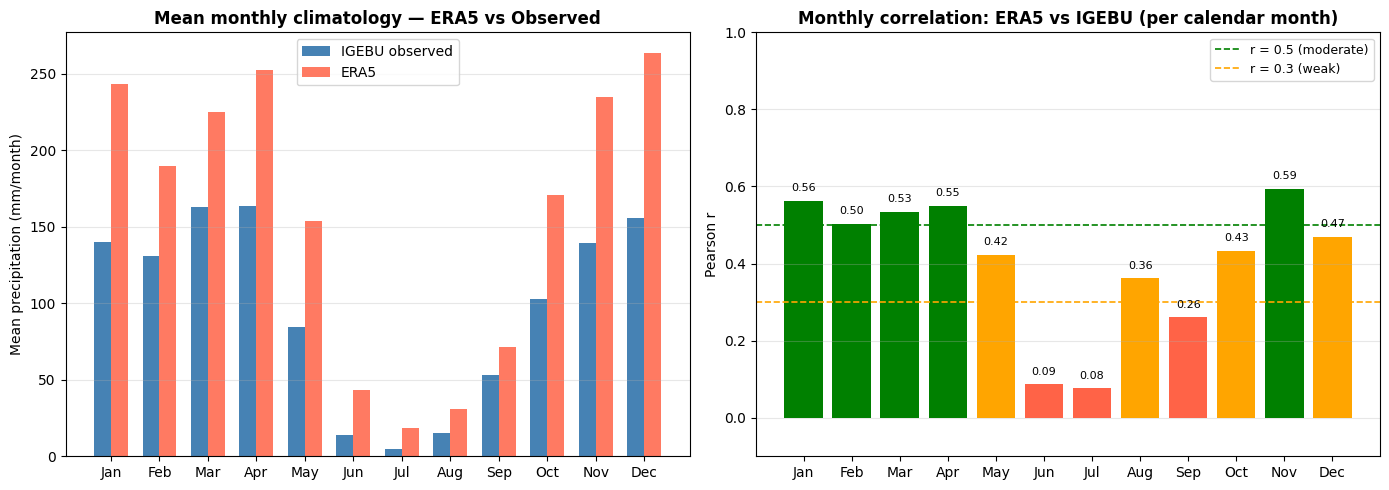

Per-calendar-month correlation (ERA5 vs IGEBU observed):
  Jan: r=+0.564  p=0.000*  n=324
  Feb: r=+0.503  p=0.000*  n=326
  Mar: r=+0.534  p=0.000*  n=323
  Apr: r=+0.549  p=0.000*  n=321
  May: r=+0.423  p=0.000*  n=321
  Jun: r=+0.087  p=0.118   n=325
  Jul: r=+0.077  p=0.168   n=326
  Aug: r=+0.362  p=0.000*  n=329
  Sep: r=+0.261  p=0.000*  n=324
  Oct: r=+0.434  p=0.000*  n=327
  Nov: r=+0.595  p=0.000*  n=324
  Dec: r=+0.469  p=0.000*  n=325
  * = statistically significant at p < 0.05


In [6]:
# --- Seasonal climatology comparison ---
monthly_clim = df.groupby("month")[["precip_observed", "era5_tp_sum"]].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(12)
w = 0.35
ax.bar(x - w/2, monthly_clim["precip_observed"], w, label="IGEBU observed", color="steelblue")
ax.bar(x + w/2, monthly_clim["era5_tp_sum"], w, label="ERA5", color="tomato", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.set_ylabel("Mean precipitation (mm/month)")
ax.set_title("Mean monthly climatology — ERA5 vs Observed", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# --- Per-calendar-month Pearson r ---
monthly_r = []
for m in range(1, 13):
    sub = df[df["month"] == m]
    if len(sub) >= 5:
        r_val, p_val = stats.pearsonr(sub["precip_observed"], sub["era5_tp_sum"])
    else:
        r_val, p_val = np.nan, np.nan
    monthly_r.append({"month": m, "r": r_val, "p": p_val, "n": len(sub)})
df_mr = pd.DataFrame(monthly_r)

ax = axes[1]
colors = ["green" if r >= 0.5 else ("orange" if r >= 0.3 else "tomato") for r in df_mr["r"]]
bars = ax.bar(df_mr["month"] - 1, df_mr["r"], color=colors)
ax.axhline(0.5, color="green", linestyle="--", linewidth=1.2, label="r = 0.5 (moderate)")
ax.axhline(0.3, color="orange", linestyle="--", linewidth=1.2, label="r = 0.3 (weak)")
ax.set_xticks(range(12))
ax.set_xticklabels(month_names)
ax.set_ylabel("Pearson r")
ax.set_ylim(-0.1, 1.0)
ax.set_title("Monthly correlation: ERA5 vs IGEBU (per calendar month)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
for bar, row in zip(bars, df_mr.itertuples()):
    if not np.isnan(row.r):
        ax.text(bar.get_x() + bar.get_width()/2, row.r + 0.02,
                f"{row.r:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

print("Per-calendar-month correlation (ERA5 vs IGEBU observed):")
for row in df_mr.itertuples():
    sig = "*" if row.p < 0.05 else " "
    print(f"  {month_names[row.month-1]:>3}: r={row.r:+.3f}  p={row.p:.3f}{sig}  n={row.n}")
print("  * = statistically significant at p < 0.05")

Overall Pearson r per river (ERA5 vs IGEBU observed):
River                     r        p      n   bias (mm)
----------------------------------------------------------
Buzimba              +0.826  0.0000    256      +280.4
Jiji                 +0.837  0.0000    525       +44.7
Kaburantwa           +0.453  0.0000    351       -45.1
Mpanda               +0.847  0.0000    185       +92.2
Mulembwe             +0.819  0.0000    518      +258.6
Mutimbuzi            +0.462  0.0000    430       -23.4
Nyakagunda           +0.587  0.0000    370       -41.0
Nyamagana            +0.449  0.0000    370       -44.6
Nyengwe              +0.836  0.0000    363      +167.0
Rusizi               +0.475  0.0000    527       -22.4


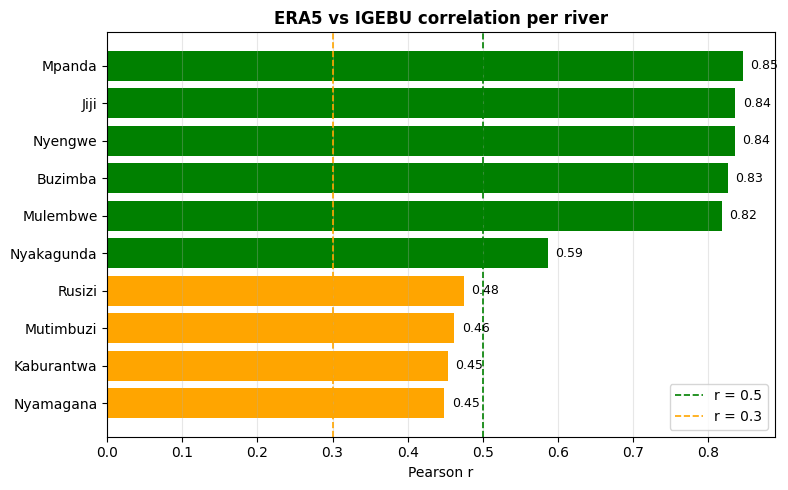

In [7]:
# --- Per-river overall correlation ---
print("Overall Pearson r per river (ERA5 vs IGEBU observed):")
print(f"{'River':<20} {'r':>6}  {'p':>7}  {'n':>5}  {'bias (mm)':>10}")
print("-" * 58)
per_river_results = []
for river in sorted(df["river"].unique()):
    sub = df[df["river"] == river]
    if len(sub) >= 5:
        r_val, p_val = stats.pearsonr(sub["precip_observed"], sub["era5_tp_sum"])
        bias = (sub["era5_tp_sum"] - sub["precip_observed"]).mean()
        print(f"{river:<20} {r_val:+.3f}  {p_val:.4f}  {len(sub):>5}  {bias:>+10.1f}")
        per_river_results.append({"river": river, "r": r_val, "p": p_val, "n": len(sub), "bias": bias})
    else:
        print(f"{river:<20}  (insufficient data, n={len(sub)})")

# Bar chart of per-river correlation
df_prr = pd.DataFrame(per_river_results).sort_values("r", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["green" if r >= 0.5 else ("orange" if r >= 0.3 else "tomato") for r in df_prr["r"]]
bars = ax.barh(df_prr["river"], df_prr["r"], color=colors)
ax.axvline(0.5, color="green", linestyle="--", linewidth=1.2, label="r = 0.5")
ax.axvline(0.3, color="orange", linestyle="--", linewidth=1.2, label="r = 0.3")
ax.set_xlabel("Pearson r")
ax.set_title("ERA5 vs IGEBU correlation per river", fontweight="bold")
ax.legend()
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, df_prr["r"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Why does the per-river correlation split into two groups?

The bar chart above shows a clear split: five rivers with r ≈ 0.82–0.85 and five rivers with r ≈ 0.45–0.59.
This is **not caused by the rivers themselves** — it is caused entirely by **which IGEBU precipitation station supplies the observed data** for each river.

The IGEBU dataset contains precipitation measurements from 6 climate stations spread across northern Burundi. Each river is assigned the nearest station's precipitation record as its `precip_observed` value. The correlation with ERA5 therefore reflects how well ERA5 agrees with *that particular station*, not with the river.

---

### Which rivers use which precipitation station

Each river's `precip_observed` column contains data from one IGEBU climate station, not from a gauge at the river itself.

| River | Gauge station (name in brackets = gauge name) | Gauge elevation | Precipitation source | ERA5 r |
|---|---|---|---|---|
| Buzimba | Buzimba (Gatete) | 810 m | NYANZA LAC (IRAT) | **0.826** |
| Nyengwe | Nyengwe (Rimbo) | 798 m | NYANZA LAC (IRAT) | **0.836** |
| Mulembwe | Mulembwe (Mutambara) | 780 m | MPOTA (Tora) | **0.819** |
| Jiji | Jiji (Ndago) | 1,840 m | MPOTA (Tora) | **0.837** |
| Mpanda | Mpanda (Gatura) | 940 m | RWEGURA | **0.847** |
| Mutimbuzi | Mutimbuzi (Pont Aéroport) | 776 m | BUJUMBURA (Aéroport) | 0.462 |
| Rusizi | Rusizi (Gatumba) | 774 m | BUJUMBURA (Aéroport) | 0.475 |
| Kaburantwa | Kaburantwa (Mission) | 800 m | MPARAMBO | 0.453 |
| Nyamagana | Nyamagana (Murambi) | 892 m | MPARAMBO | 0.449 |
| Nyakagunda | Nyakagunda (Musenyi) | 1,000 m | MPARAMBO | 0.587 |

> **Note on station names:** The name in parentheses after each river (e.g. "Gatete", "Rimbo", "Ndago") is the local name of the specific gauge site on that river — often a village, bridge, or landmark near the measurement point.

---